<a href="https://colab.research.google.com/github/JayNguyen-123/Customer-Segmentation-using-PySpark/blob/main/Customer_Segmentation_PySpark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Customer Segmentation using PySpark
Why use PySpark?
- Quickly process big data.
- Faster than traditional libraries like Pandas, Dash
_ Handle large amount of data than these frameworks.

Customer Segmentation
- Customer segmentation is a marketing technique companies use to identify and group users who display similar characteristics.
- The popular model to for Customer Segmentation is K-Means Clustering.

In [32]:
import warnings
warnings.filterwarnings('ignore')
from pyspark.sql import SparkSession


### Create Spark Session
- A SparkSession is an entry point into all functionality in Spark, and is required if you want to build a dataframe in PySpark.

In [33]:
from pyspark.sql import SparkSession

sparks = (
    SparkSession.builder
    .appName("Customer Segmentation")              # Set the name
    .config("spark.memory.enabled", "true")         # avoid storing data directly on disk
    .congig("spark.memory.offHeap.size", "10g")       # specify amount of memory
    .getOrCreate()
)

In [42]:
# Create the DataFrame
df = spark.read.csv('/content/datalab_export_2025-09-26 18_40_53.csv',header=True,escape="\"")
df.show(20,0)


+-----+---------+---------+-----------------------------------+--------+------------+---------+----------+--------------+
|index|InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate |UnitPrice|CustomerID|Country       |
+-----+---------+---------+-----------------------------------+--------+------------+---------+----------+--------------+
|1    |536365   |85123A   |WHITE HANGING HEART T-LIGHT HOLDER |6       |12/1/10 8:26|2.55     |17850     |United Kingdom|
|2    |536365   |71053    |WHITE METAL LANTERN                |6       |12/1/10 8:26|3.39     |17850     |United Kingdom|
|3    |536365   |84406B   |CREAM CUPID HEARTS COAT HANGER     |8       |12/1/10 8:26|2.75     |17850     |United Kingdom|
|4    |536365   |84029G   |KNITTED UNION FLAG HOT WATER BOTTLE|6       |12/1/10 8:26|3.39     |17850     |United Kingdom|
|5    |536365   |84029E   |RED WOOLLY HOTTIE WHITE HEART.     |6       |12/1/10 8:26|3.39     |17850     |United Kingdom|
|6    |536365   |22752  

In [43]:
df.count()


100

In [44]:
from pyspark.sql.functions import *
from pyspark.sql.types import *

df.groupBy('Country').agg(countDistinct('CustomerID').alias('country_count')).show()


+--------------+-------------+
|       Country|country_count|
+--------------+-------------+
|        France|            1|
|United Kingdom|            6|
+--------------+-------------+



In [46]:
# counting the number of unique customers for each country in the DataFrame and displaying the results in descending order.
df.groupBy('Country').agg(countDistinct('CustomerID').alias('country_count')).orderBy(desc('country_count')).show()


+--------------+-------------+
|       Country|country_count|
+--------------+-------------+
|United Kingdom|            6|
|        France|            1|
+--------------+-------------+



In [47]:
# Find the most recent purchase made by a customer
spark.sql("set spark.sql.legacy.timeParserPolicy=LEGACY")
df = df.withColumn('date',to_timestamp("InvoiceDate", 'yy/MM/dd HH:mm'))
df.select(max("date")).show()


+-------------------+
|          max(date)|
+-------------------+
|2012-01-10 09:37:00|
+-------------------+



In [49]:
# Find the earliest purchase date and time
df.select(min("date")).show()



+-------------------+
|          min(date)|
+-------------------+
|2012-01-10 08:26:00|
+-------------------+



In [50]:
# Data Preprocessing
df.show(5,0)


+-----+---------+---------+-----------------------------------+--------+------------+---------+----------+--------------+-------------------+
|index|InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate |UnitPrice|CustomerID|Country       |date               |
+-----+---------+---------+-----------------------------------+--------+------------+---------+----------+--------------+-------------------+
|1    |536365   |85123A   |WHITE HANGING HEART T-LIGHT HOLDER |6       |12/1/10 8:26|2.55     |17850     |United Kingdom|2012-01-10 08:26:00|
|2    |536365   |71053    |WHITE METAL LANTERN                |6       |12/1/10 8:26|3.39     |17850     |United Kingdom|2012-01-10 08:26:00|
|3    |536365   |84406B   |CREAM CUPID HEARTS COAT HANGER     |8       |12/1/10 8:26|2.75     |17850     |United Kingdom|2012-01-10 08:26:00|
|4    |536365   |84029G   |KNITTED UNION FLAG HOT WATER BOTTLE|6       |12/1/10 8:26|3.39     |17850     |United Kingdom|2012-01-10 08:26:00|
|5    

### Recency
-  let’s calculate the value of recency - the latest date and time a purchase was made on the platform. This can be achieved in two steps:
1. Assign a recency score to each customer We will subtract every date in the dataframe from the earliest date. This will tell us how recently a customer was seen in the dataframe. A value of 0 indicates the lowest recency, as it will be assigned to the person who was seen making a purchase on the earliest date.

In [51]:
df = df.withColumn("from_date", lit("12/1/10 08:26"))
df = df.withColumn("from_date", to_timestamp("from_date", "yy/MM/dd HH:mm"))

df2 = df.withColumn('recency', col("date").cast("long") - col("from_date").cast("long"))


In [52]:
df2.show(5)


+-----+---------+---------+--------------------+--------+------------+---------+----------+--------------+-------------------+-------------------+-------+
|index|InvoiceNo|StockCode|         Description|Quantity| InvoiceDate|UnitPrice|CustomerID|       Country|               date|          from_date|recency|
+-----+---------+---------+--------------------+--------+------------+---------+----------+--------------+-------------------+-------------------+-------+
|    1|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/10 8:26|     2.55|     17850|United Kingdom|2012-01-10 08:26:00|2012-01-10 08:26:00|      0|
|    2|   536365|    71053| WHITE METAL LANTERN|       6|12/1/10 8:26|     3.39|     17850|United Kingdom|2012-01-10 08:26:00|2012-01-10 08:26:00|      0|
|    3|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/10 8:26|     2.75|     17850|United Kingdom|2012-01-10 08:26:00|2012-01-10 08:26:00|      0|
|    4|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/10 8:26|

2. Select the most recent purchase

- One customer can make multiple purchases at different times. We need to select only the last time they were seen buying a product, as this is indicative of when the most recent purchase was made.

In [53]:
df2 = df2.join(df2.groupBy('CustomerID').agg(max('recency').alias('recency')), on='recency', how='leftsemi')

df2.show(5,0)


+-------+-----+---------+---------+-------------------------------+--------+------------+---------+----------+--------------+-------------------+-------------------+
|recency|index|InvoiceNo|StockCode|Description                    |Quantity|InvoiceDate |UnitPrice|CustomerID|Country       |date               |from_date          |
+-------+-----+---------+---------+-------------------------------+--------+------------+---------+----------+--------------+-------------------+-------------------+
|540    |26   |536369   |21756    |BATH BUILDING BLOCK WORD       |3       |12/1/10 8:35|5.95     |13047     |United Kingdom|2012-01-10 08:35:00|2012-01-10 08:26:00|
|1140   |27   |536370   |22728    |ALARM CLOCK BAKELIKE PINK      |24      |12/1/10 8:45|3.75     |12583     |France        |2012-01-10 08:45:00|2012-01-10 08:26:00|
|1140   |28   |536370   |22727    |ALARM CLOCK BAKELIKE RED       |24      |12/1/10 8:45|3.75     |12583     |France        |2012-01-10 08:45:00|2012-01-10 08:26:00|
|114

In [54]:
df2.printSchema()     # similar to info() in pandas


root
 |-- recency: long (nullable = true)
 |-- index: string (nullable = true)
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: string (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: string (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- from_date: timestamp (nullable = true)



# Frequency
- Let’s now calculate the value of frequency - how often a customer bought something on the platform. To do this, we just need to group by each customer ID and count the number of items they purchased.


In [57]:
# alias() to rename the resulting column to frequency
# agg() used to aggregate the data in each group
df_freq = df2.groupBy('CustomerID').agg(count('InvoiceDate').alias('frequency'))

df_freq.show(5,0)


+----------+---------+
|CustomerID|frequency|
+----------+---------+
|15100     |1        |
|15291     |2        |
|17850     |18       |
|13748     |1        |
|12583     |20       |
+----------+---------+
only showing top 5 rows



In [58]:
df3 = df2.join(df_freq, on='CustomerID', how='inner')
df.printSchema()


root
 |-- index: string (nullable = true)
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: string (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: string (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- from_date: timestamp (nullable = true)



### Monetary Value
- let’s calculate monetary value - the total amount spent by each customer in the dataframe. There are two steps to achieving this:
1. Find the total amount spent in each purchase: Each customerID comes with variables called “Quantity” and “UnitPrice” for a single purchase:

In [59]:
m_val = df3.withColumn('TotalAmount', col('Quantity') * col('UnitPrice'))


2. Find the total amount spent by each customer:

To find the total amount spent by each customer overall, we just need to group by the CustomerID column and sum the total amount spent.

In [60]:
m_val = m_val.groupBy('CustomerID').agg(sum('TotalAmount').alias('Monetary_value'))


In [61]:
# Merge this dataframe with the all the other variables.
finaldf = m_val.join(df3, on='CustomerID', how='inner')


In [63]:
finaldf = finaldf.select(['recency','frequency','monetary_value','CustomerID']).distinct()

finaldf.show(5,0)


+-------+---------+------------------+----------+
|recency|frequency|monetary_value    |CustomerID|
+-------+---------+------------------+----------+
|2580   |1        |350.4             |15100     |
|3960   |2        |328.8             |15291     |
|4080   |18       |282.06000000000006|17850     |
|3960   |18       |282.06000000000006|17850     |
|2040   |1        |204.0             |13748     |
+-------+---------+------------------+----------+
only showing top 5 rows



### Standardization
- Before building the customer segmentation model, let’s standardize the dataframe to ensure that all the variables are around the same scale.


In [64]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

assemble = VectorAssembler(inputCols=[
    'recency', 'frequency', 'monetary_value'
], outputCol='features')

assembled_data = assemble.transform(finaldf)

scale = StandardScaler(inputCol='features', outputCol='standardized')
data_scale = scale.fit(assembled_data)
data_scale_output = data_scale.transform(assembled_data)


In [65]:
data_scale_output.select('standardized').show(2, truncate=False)


+-----------------------------------------------------------+
|standardized                                               |
+-----------------------------------------------------------+
|[1.7655857019430088,0.11303378701351413,1.4727975400140534]|
|[2.709968751819502,0.22606757402702826,1.3820086505611324] |
+-----------------------------------------------------------+
only showing top 2 rows



#### Building the Machine Learning Model


In [66]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import numpy as np

cost = np.zeros(10)

evaluator = ClusteringEvaluator(predictionCol='prediction',
                                featuresCol='standardized',
                                metricName='silhouette',
                                distanceMeasure='squareEuclidean')

for i in range(2, 10):
  KMeans_algo = KMeans(featuresCol='standardized', k=i)
  KMeans_fit = KMeans_algo.fit(data_scale_output)
  output = KMeans_fit.transform(data_scale_output)
  cost[i] = KMeans_fit.summary.trainingCost


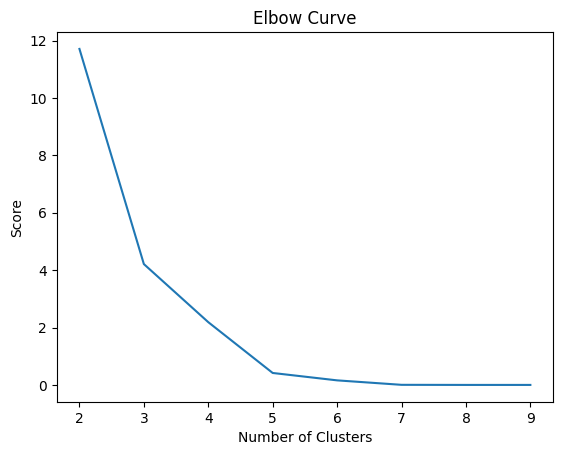

In [68]:
import pandas as pd
import pylab as pl
df_cost = pd.DataFrame(cost[2:])
df_cost.columns = ["cost"]
new_col = range(2,10)
df_cost.insert(0, 'cluster', new_col)
pl.plot(df_cost.cluster, df_cost.cost)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

### Build the K-Means Clustering Model


In [69]:
KMeans_algo = KMeans(featuresCol='standardized', k=4)
KMeans_fit = KMeans_algo.fit(data_scale_output)


In [70]:
preds = KMeans_fit.transform(data_scale_output)
preds.show(5,0)


+-------+---------+------------------+----------+--------------------------------+-----------------------------------------------------------+----------+
|recency|frequency|monetary_value    |CustomerID|features                        |standardized                                               |prediction|
+-------+---------+------------------+----------+--------------------------------+-----------------------------------------------------------+----------+
|2580   |1        |350.4             |15100     |[2580.0,1.0,350.4]              |[1.7655857019430088,0.11303378701351413,1.4727975400140534]|0         |
|3960   |2        |328.8             |15291     |[3960.0,2.0,328.8]              |[2.709968751819502,0.22606757402702826,1.3820086505611324] |3         |
|4080   |18       |282.06000000000006|17850     |[4080.0,18.0,282.06000000000006]|[2.7920890170261536,2.0346081662432542,1.1855515814393949] |2         |
|3960   |18       |282.06000000000006|17850     |[3960.0,18.0,282.0600000000

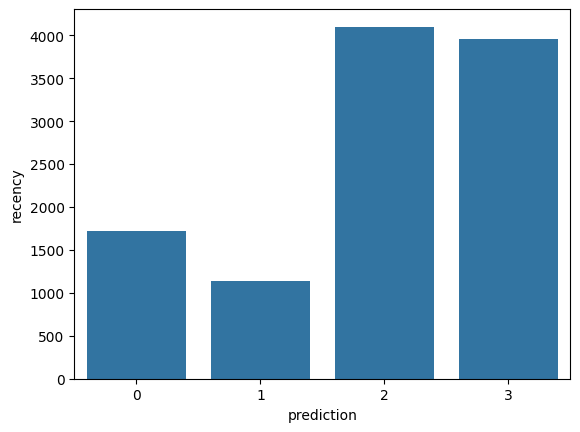

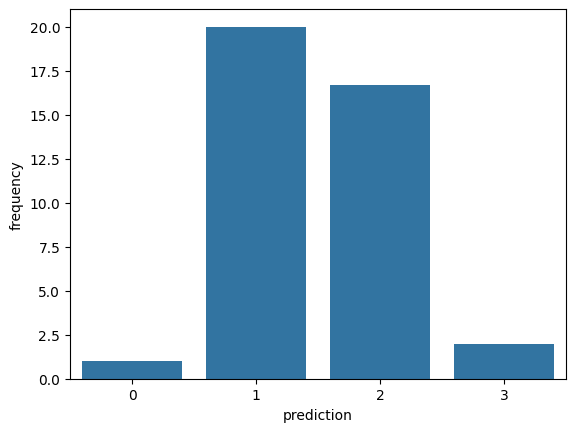

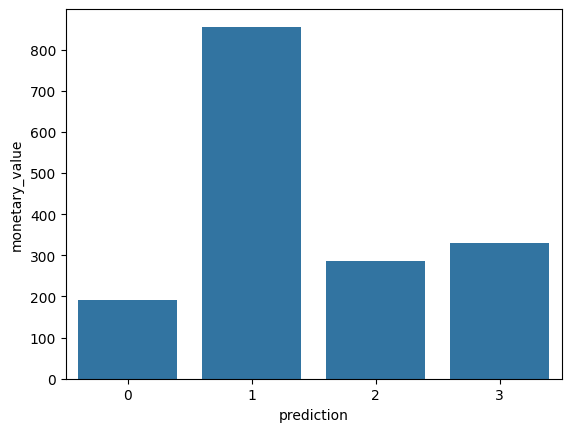

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

df_viz = preds.select('recency', 'frequency', 'monetary_value', 'prediction')
df_viz = df_viz.toPandas()
avg_df = df_viz.groupby(['prediction'], as_index=False).mean()

list1 = ['recency', 'frequency', 'monetary_value']

for i in list1:
  sns.barplot(x='prediction', y=str(i), data=avg_df)
  plt.show()


### Cluster Analysis
- Cluster 0: Customers in this segment display low recency, frequency, and monetary value. They rarely shop on the platform and are low potential customers who are likely to stop doing business with the ecommerce company.

- Cluster 1: Users in this cluster display high recency but haven’t been seen spending much on the platform. They also don’t visit the site often. This indicates that they might be newer customers who have just started doing business with the company.
- Cluster 2: Customers in this segment display medium recency and frequency and spend a lot of money on the platform. This indicates that they tend to buy high-value items or make bulk purchases.
- Cluster 3: The final segment comprises users who display high recency and make frequent purchases on the platform. However, they don’t spend much on the platform, which might mean that they tend to select cheaper items in each purchase.